In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

EOD_PATH = Path("data") / "EOD_STGO"

In [3]:
from chiricoca.config import setup_style
setup_style(dpi=192)

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import networkx as nx

In [5]:
import huedhued.eod_scl as eod

viajes = eod.read_trips(EOD_PATH)

# descartamos sectores que no sean relevantes en los orígenes y destinos de los viajes
viajes = viajes[
    (viajes["SectorOrigen"] != "Exterior a RM")
    & (viajes["SectorDestino"] != "Exterior a RM")
    & (viajes["SectorOrigen"] != "Extensión Sur-Poniente")
    & (viajes["SectorDestino"] != "Extensión Sur-Poniente")
    & pd.notnull(viajes["SectorOrigen"])
    & pd.notnull(viajes["SectorDestino"])
]

personas = eod.read_people(EOD_PATH)

viajes_persona = viajes.merge(personas)

viajes_persona["Peso"] = (
    viajes_persona["FactorExpansion"] * viajes_persona["FactorPersona"]
)

print(
    "{} viajes expandidos a {}".format(
        len(viajes_persona), int(viajes_persona["Peso"].sum())
    )
)

83439 viajes expandidos a 12188506


In [6]:
viajes_persona['DondeEstudia'].value_counts()

DondeEstudia
4.0    11362
8.0     4650
7.0     1314
3.0     1127
2.0     1005
6.0      368
9.0      260
5.0      128
1.0      106
Name: count, dtype: int64

In [7]:
!cat "data/EOD_STGO/Tablas_parametros/Donde Estudia.csv"

Id;DondeEstudia
1;Sala cuna
2;Jardín infantil
3;Prekínder o kínder
4;Escuela, liceo o colegio
5;Sólo preuniversitario
6;Centro de formación técnica
7;Instituto profesional
8;Universidad
9;Otro


In [45]:
viajes_esup = viajes_persona[
    viajes_persona["DondeEstudia"].between(5, 9)
    & (viajes_persona["Proposito"].isin(["Al estudio", 'Por estudio']))
].drop_duplicates(subset="Persona", keep="first")
viajes_esup

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,IngresoFinal,TramoIngresoFinal,IngresoImputado,Factor_LaboralNormal,Factor_SabadoNormal,Factor_DomingoNormal,Factor_LaboralEstival,Factor_FindesemanaEstival,FactorPersona,Peso
24,173481,17348103,1734810301,2,Maipú,Santiago,Poniente,Centro,398,23,...,0,0,0,35.97286,NaN,NaN,NaN,NaN,18.02301,18.023010
26,173481,17348104,1734810401,2,Maipú,Santiago,Poniente,Centro,398,23,...,0,0,0,35.96394,NaN,NaN,NaN,NaN,17.25172,19.446481
59,101220,10122004,1012200402,1,Santiago,Santiago,Centro,Centro,20,15,...,348654,2,2,1043.70600,NaN,NaN,NaN,NaN,812.51886,855.390248
62,101562,10156203,1015620302,1,Providencia,Santiago,Oriente,Centro,498,7,...,540520,3,2,107.13300,NaN,NaN,NaN,NaN,137.41714,144.667758
98,101721,10172103,1017210301,3,Calera de Tango,Santiago,Sur,Centro,798,15,...,0,0,0,26.52504,NaN,NaN,NaN,NaN,2.56708,2.702528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82948,329001,32900103,3290010301,1,La Cisterna,Providencia,Sur,Oriente,187,511,...,66626,1,1,247.21490,NaN,NaN,NaN,NaN,121.12041,136.529330
82952,329001,32900106,3290010601,1,La Cisterna,Santiago,Sur,Centro,187,7,...,0,0,0,247.53880,NaN,NaN,NaN,NaN,155.58459,127.253780
82961,329271,32927103,3292710301,1,La Cisterna,Estación Central,Sur,Poniente,180,129,...,0,0,0,94.83472,NaN,NaN,NaN,NaN,52.88689,59.615152
83060,343783,34378304,3437830401,1,Quinta Normal,Santiago,Poniente,Centro,572,15,...,0,0,0,NaN,NaN,6172.061,NaN,NaN,10.67313,10.673130


<Axes: xlabel='ComunaDestino', ylabel='ComunaOrigen'>

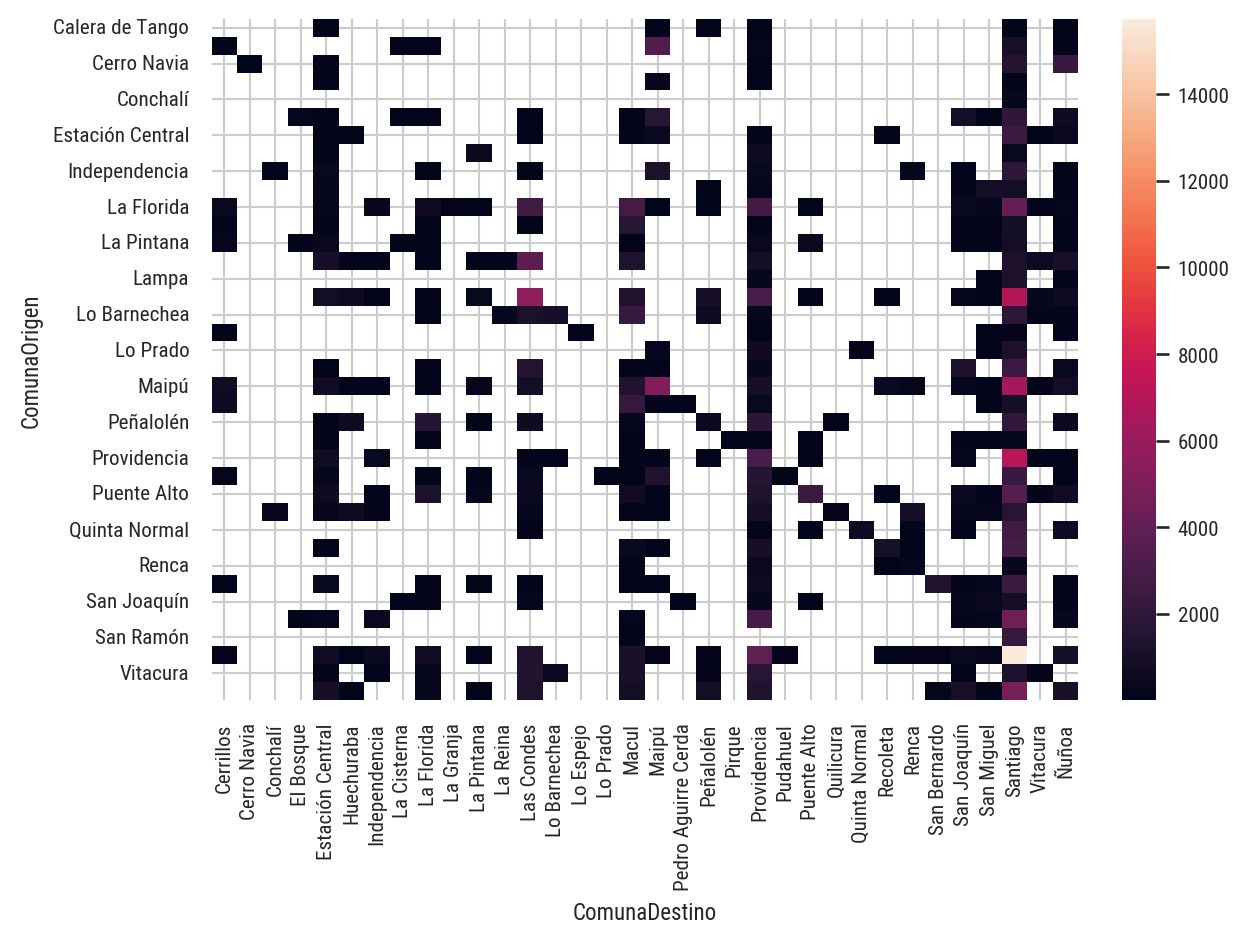

In [9]:
sns.heatmap(viajes_esup.groupby(['ComunaOrigen', 'ComunaDestino'])['Peso'].sum().unstack())

In [10]:
import geopandas as gpd

comunas = gpd.read_file('data/comunas_rm/COMUNA_C17.shp')
comunas.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-70.61889 -33.73808, -70.61811 -33.7..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-70.63192 -33.64634, -70.63207 -33.6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-70.78914 -33.36153, -70.78824 -33.3..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-70.59630 -32.95138, -70.59673 -32.9..."


/home/egraells/resources/visualization-course-materials/chiricoca/geo/utils.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ).pipe(lambda x: x[x.geometry.area > 0])


<Axes: >

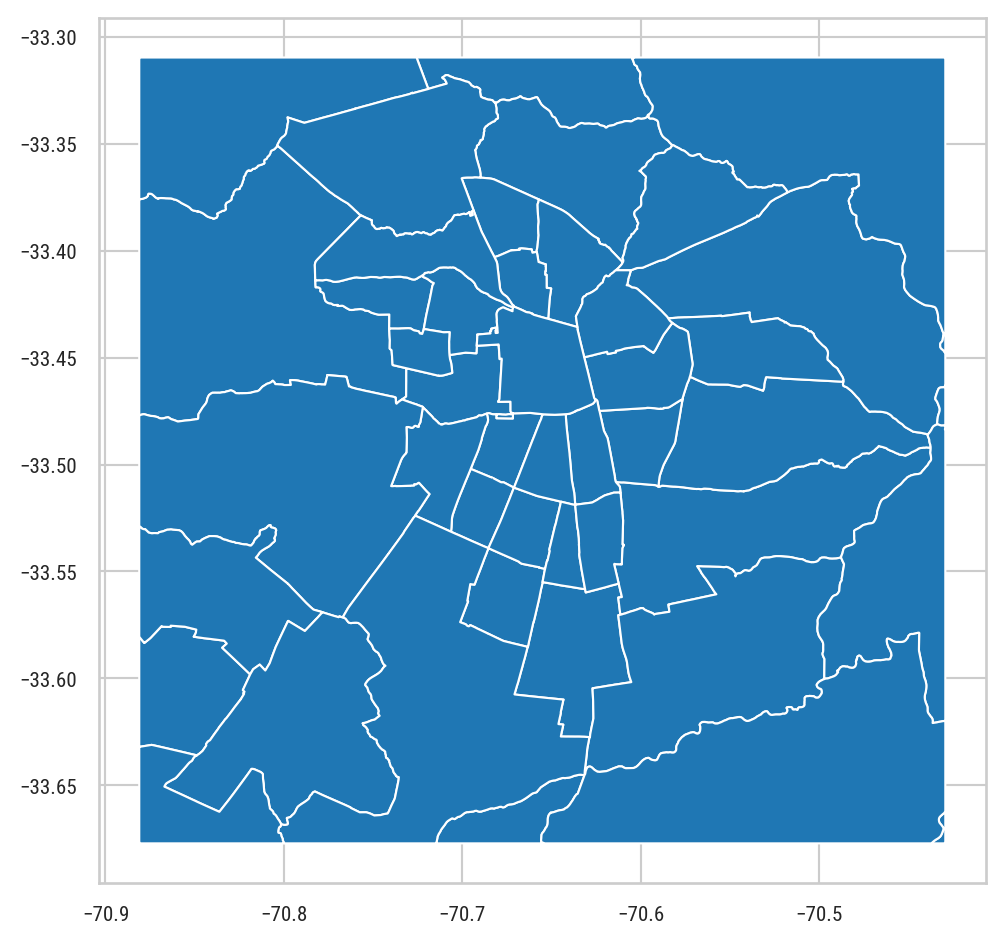

In [11]:
from chiricoca.geo.utils import clip_area_geodataframe

bounding_box = [-70.88006218, -33.67612715, -70.43015094, -33.31069169]
comunas_urbanas = clip_area_geodataframe(comunas, bounding_box, buffer=0.001)

comunas_urbanas.plot()

In [12]:
comunas_urbanas['NOM_COMUNA']

1                    BUIN
2                PUDAHUEL
3             CERRO NAVIA
4                  COLINA
6                   LAMPA
7              HUECHURABA
8                CONCHALÍ
11             LA PINTANA
12              EL BOSQUE
13       ESTACIÓN CENTRAL
14    PEDRO AGUIRRE CERDA
15               RECOLETA
16          INDEPENDENCIA
18              LO ESPEJO
19            LA CISTERNA
20             LA FLORIDA
21              PEÑALOLÉN
22             LAS CONDES
23               LA REINA
24           LO BARNECHEA
25               VITACURA
26          QUINTA NORMAL
27               LO PRADO
28              CERRILLOS
29                  MAIPÚ
31                  MACUL
32                  ÑUÑOA
33               PEÑAFLOR
34          PADRE HURTADO
35            PUENTE ALTO
36              QUILICURA
37                  RENCA
38        CALERA DE TANGO
39           SAN BERNARDO
40      SAN JOSÉ DE MAIPO
41                 PIRQUE
42            SAN JOAQUÍN
43             SAN MIGUEL
44          

In [75]:
comunas_a_filtrar = set(comunas_urbanas['NOM_COMUNA']) - set(viajes_esup['ComunaOrigen'].str.upper().unique())
comunas_a_filtrar

{'BUIN', 'PADRE HURTADO', 'PEÑAFLOR', 'SAN JOSÉ DE MAIPO', 'TALAGANTE'}

In [74]:
#set(viajes_esup['ComunaOrigen'].str.upper().unique()) - comunas_a_filtrar

In [15]:
viajes_od = (
    viajes_esup[
        viajes_esup["ComunaOrigen"].str.upper().isin(comunas_urbanas["NOM_COMUNA"])
        & viajes_esup["ComunaDestino"].str.upper().isin(comunas_urbanas["NOM_COMUNA"])
    ]
    .assign(ComunaOrigen=lambda x: x["ComunaOrigen"].str.upper())
    .assign(ComunaDestino=lambda x: x["ComunaDestino"].str.upper())
)

# comunas_validas = set(viajes_esup['ComunaOrigen'].str.upper().unique())

In [16]:
od_matrix = (
    viajes_od.groupby(["ComunaOrigen", "ComunaDestino"])["Peso"].sum().reset_index()
)

od_matrix.describe()

,Peso
count,360.000000
mean,663.439293
std,1319.455023
min,1.562219
25%,62.140890
50%,198.213336
75%,733.338504
max,15748.510689


In [17]:
od_network = nx.from_pandas_edgelist(
    od_matrix[
        (od_matrix["Peso"] >= od_matrix["Peso"].quantile(0.5))
        & (od_matrix["ComunaOrigen"] != od_matrix["ComunaDestino"])
    ],
    source="ComunaOrigen",
    target="ComunaDestino",
    create_using=nx.DiGraph,
    edge_attr=["Peso"],
)

In [18]:

geo_pos = (
    comunas_urbanas.set_index("NOM_COMUNA").centroid.map(lambda x: (x.x, x.y)).to_dict()
)
geo_pos

/tmp/ipykernel_8348/4286976415.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  comunas_urbanas.set_index("NOM_COMUNA").centroid.map(lambda x: (x.x, x.y)).to_dict()


{'BUIN': (-70.67141632255544, -33.66502528112296),
 'PUDAHUEL': (-70.81886296820149, -33.42177325330977),
 'CERRO NAVIA': (-70.74411537750484, -33.42223022060807),
 'COLINA': (-70.64897267353645, -33.32254192278055),
 'LAMPA': (-70.8222696630937, -33.33646062772215),
 'HUECHURABA': (-70.63763627369089, -33.36019497768805),
 'CONCHALÍ': (-70.67659284963145, -33.38339574510986),
 'LA PINTANA': (-70.63710981246093, -33.587589410608956),
 'EL BOSQUE': (-70.67621430116998, -33.562769176108894),
 'ESTACIÓN CENTRAL': (-70.70072365755654, -33.46407428406909),
 'PEDRO AGUIRRE CERDA': (-70.6754523048463, -33.491494693566345),
 'RECOLETA': (-70.63930739878904, -33.40528226208009),
 'INDEPENDENCIA': (-70.6650568221164, -33.414401448581266),
 'LO ESPEJO': (-70.68973828542875, -33.520415679638276),
 'LA CISTERNA': (-70.66377189171165, -33.53006947995767),
 'LA FLORIDA': (-70.53984933631125, -33.52812687920012),
 'PEÑALOLÉN': (-70.52509374438131, -33.48519517321457),
 'LAS CONDES': (-70.5007903506805

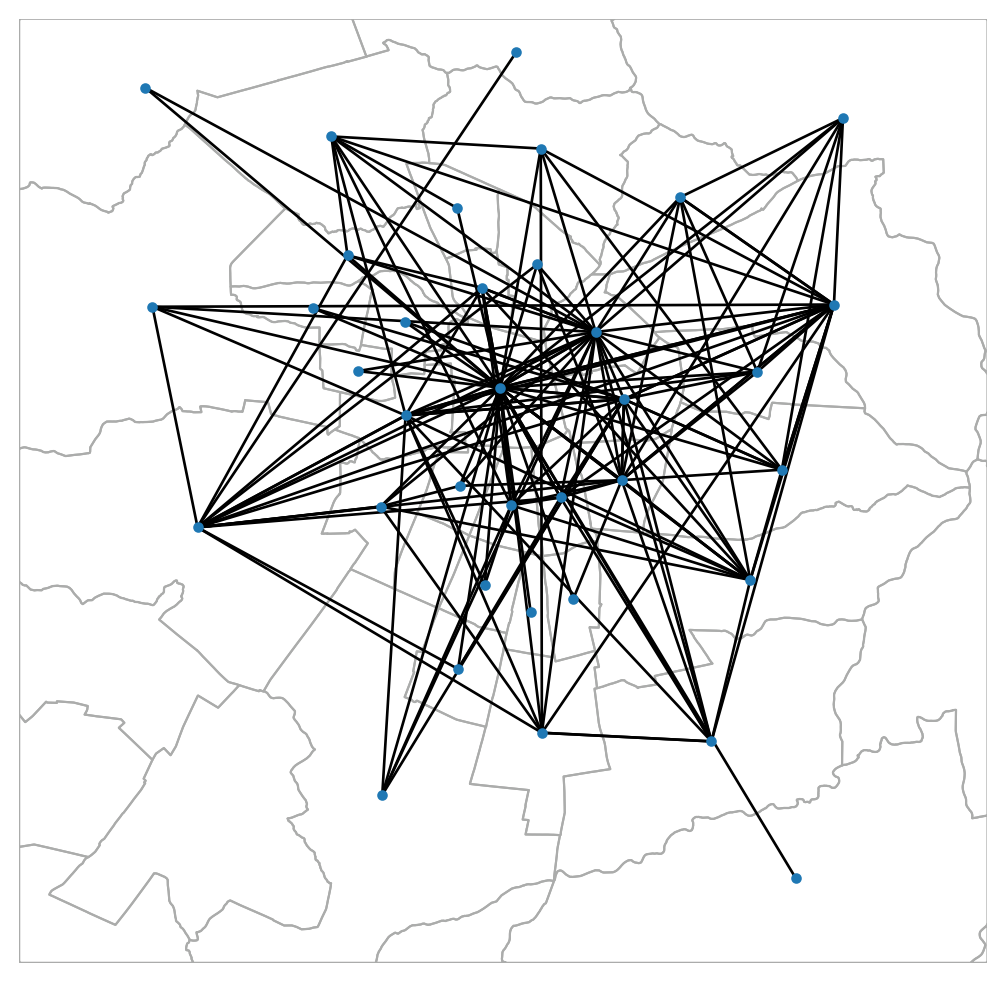

In [19]:
from chiricoca.geo.figures import figure_from_geodataframe

fig, ax = figure_from_geodataframe(comunas_urbanas) 
comunas_urbanas.plot(ax=ax, facecolor='none', edgecolor='#abacab')

nx.draw_networkx(od_network, pos=geo_pos, with_labels=False, node_size=10, arrows=False, ax=ax)


In [20]:
edge_weight = pd.Series(nx.get_edge_attributes(od_network, 'Peso'))
edge_weight

CERRILLOS            MAIPÚ               3301.590564
                     PROVIDENCIA          210.533920
                     SANTIAGO             997.618116
MAIPÚ                CERRILLOS            705.258996
                     ESTACIÓN CENTRAL     691.950712
                     LA PINTANA           203.388522
                     LAS CONDES           847.795817
                     MACUL               1414.253668
                     PROVIDENCIA          979.576852
                     RECOLETA             367.171581
                     RENCA                210.515900
                     SAN JOAQUÍN          279.985569
                     SANTIAGO            6365.119036
                     ÑUÑOA                763.949317
PROVIDENCIA          ESTACIÓN CENTRAL     727.607511
                     INDEPENDENCIA        349.896451
                     SANTIAGO            7196.646325
SANTIAGO             ESTACIÓN CENTRAL     687.252267
                     INDEPENDENCIA        392.

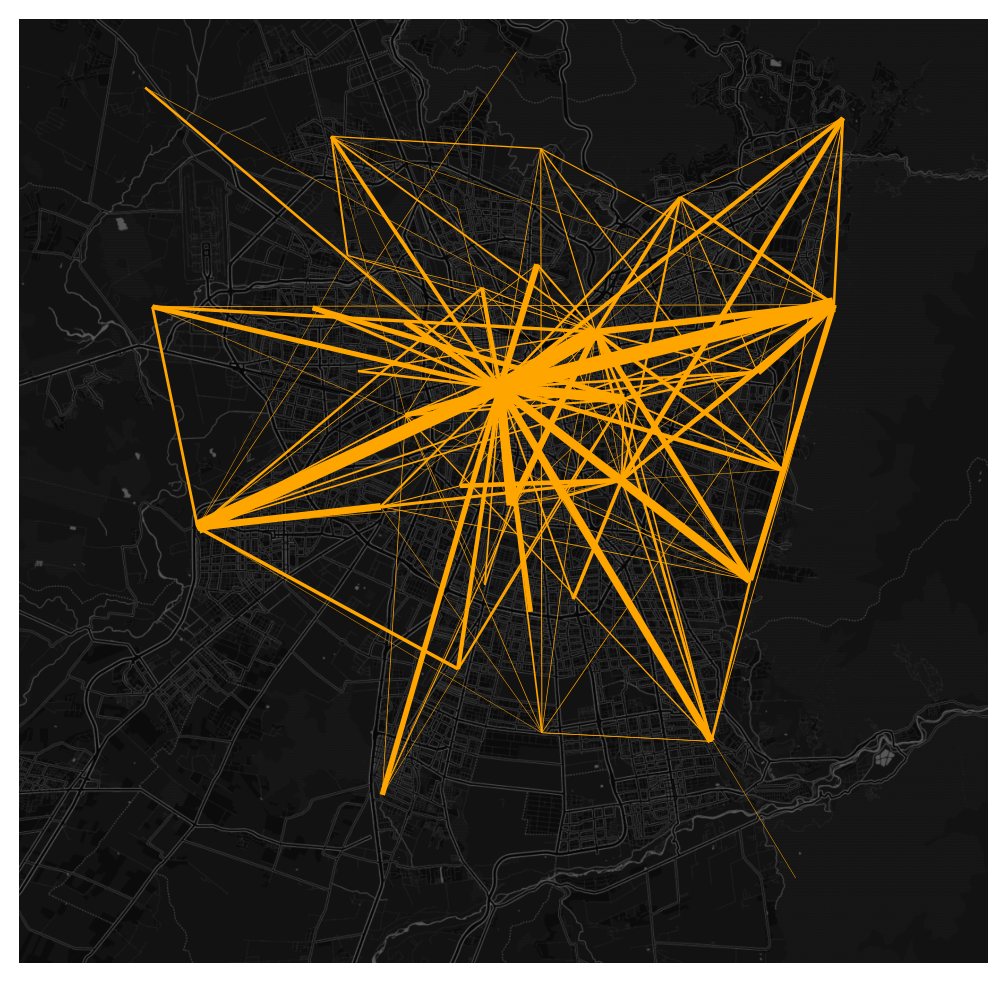

In [21]:
from chiricoca.maps.utils import add_basemap

fig, ax = figure_from_geodataframe(comunas_urbanas)

add_basemap(ax, Path("data") / "scl_network_basemap.tif", comunas_urbanas)

nx.draw_networkx_edges(
    od_network,
    pos=geo_pos,
    arrows=False,
    width=edge_weight / edge_weight.sum() * 150,
    alpha=1.0,
    ax=ax,
    edge_color='orange'
)

    # node_df_norm = pd.Series(nx.get_node_attributes(_od, 'node_centrality'))
    # node_df_norm = node_df_norm / node_df_norm.sum() * 3000
    # nx.draw_networkx_nodes(_od, pos=geo_pos, node_size=node_df_norm, ax=ax, node_color='white', edgecolors='black', linewidths=0.5)
    # ax.set_title(f'{_sex}')

In [22]:
from chiricoca.geo.utils import to_point_geodataframe

esup_origins = to_point_geodataframe(viajes_esup, 'OrigenCoordX', 'OrigenCoordY', crs='epsg:5361').to_crs(comunas_urbanas.crs)

esup_destinations = to_point_geodataframe(viajes_esup, 'DestinoCoordX', 'DestinoCoordY', crs='epsg:5361').to_crs(comunas_urbanas.crs)

In [23]:
import h3
import geopandas as gpd
from shapely.geometry import Polygon

def h3_grid(bounds, extra_margin=0.0, grid_level=12, crs="epsg:4326"):
    class MockGeo:
        def __init__(self, d):
            self.d = d

        @property
        def __geo_interface__(self):
            return self.d
    
    bounds = list(bounds)
    bounds[0] = bounds[0] - extra_margin * (bounds[2] - bounds[0])
    bounds[2] = bounds[2] + extra_margin * (bounds[2] - bounds[0])
    bounds[1] = bounds[1] - extra_margin * (bounds[3] - bounds[1])
    bounds[3] = bounds[3] + extra_margin * (bounds[3] - bounds[1])

    cell_ids = h3.h3shape_to_cells(
        h3.geo_to_h3shape(
            MockGeo(
                {
                    "type": "Polygon",
                    "coordinates": [
                        [
                            [bounds[0], bounds[1]],
                            [bounds[2], bounds[1]],
                            [bounds[2], bounds[3]],
                            [bounds[0], bounds[3]],
                        ]
                    ],
                }
            )
        ),
        res=grid_level,
    )

    h3grid = gpd.GeoDataFrame(
        {"h3_cell_id": list(map(str, cell_ids))},
        geometry=[
            Polygon(
                list(
                    map(lambda x: tuple(reversed(x)), h3.cell_to_boundary(cell_id))
                )
            )
            for cell_id in cell_ids
        ],
        crs="epsg:4326",
    ).to_crs(crs)

    return h3grid

In [24]:
grid = h3_grid(comunas_urbanas.total_bounds, extra_margin=0.05, grid_level=7)

In [25]:
origins_in_grid = gpd.sjoin(esup_origins, grid, op="within", how="inner").groupby('h3_cell_id')['Peso'].sum().rename('n_origin')
destinations_in_grid = gpd.sjoin(esup_destinations, grid, op="within", how="inner").groupby('h3_cell_id')['Peso'].sum().rename('n_destination')

/home/egraells/miniconda3/envs/aves/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3519: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
/tmp/ipykernel_8348/367052982.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4674
Right CRS: EPSG:4326

  origins_in_grid = gpd.sjoin(esup_origins, grid, op="within", how="inner").groupby('h3_cell_id')['Peso'].sum().rename('n_origin')
/home/egraells/miniconda3/envs/aves/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3519: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
/tmp/ipykernel_8348/3670529

In [26]:
from chiricoca.base.weights import normalize_rows

grid_diff = (
    destinations_in_grid.to_frame()
    .join(origins_in_grid, how="outer")
    .fillna(0)
    #.pipe(normalize_rows)
    .assign(diff=lambda x: x["n_destination"] - x["n_origin"])
)
grid_diff.describe()

,n_destination,n_origin,diff
count,190.000000,190.000000,190.000000
mean,1257.042870,1251.783085,5.259785
std,4517.097596,1601.441566,3978.243363
min,0.000000,0.000000,-5227.710536
25%,0.000000,199.484308,-1101.848633
50%,50.821150,716.941392,-376.011945
75%,553.386764,1809.370889,-12.874372
max,40284.531455,13488.887602,38253.592381


In [27]:
grid.join(grid_diff,
        on="h3_cell_id",
        how="inner",
    )

,h3_cell_id,geometry,n_destination,n_origin,diff
5,87b2c5cd6ffffff,"POLYGON ((-70.75646 -33.28132, -70.76467 -33.2...",0.000000,48.091488,-48.091488
16,87b2c5cdaffffff,"POLYGON ((-70.71861 -33.34050, -70.72681 -33.3...",0.000000,329.616206,-329.616206
17,87b2c5704ffffff,"POLYGON ((-70.54817 -33.60582, -70.55637 -33.6...",132.702290,71.706873,60.995417
18,87b2c540cffffff,"POLYGON ((-70.80008 -33.51092, -70.80830 -33.5...",0.000000,1288.814565,-1288.814565
23,87b2c5706ffffff,"POLYGON ((-70.57088 -33.61615, -70.57908 -33.6...",0.000000,536.771593,-536.771593
36,87b2c5408ffffff,"POLYGON ((-70.80199 -33.53082, -70.81020 -33.5...",0.000000,757.982608,-757.982608
40,87b2c57adffffff,"POLYGON ((-70.62008 -33.67650, -70.62829 -33.6...",0.000000,21.201811,-21.201811
44,87b2c54c1ffffff,"POLYGON ((-70.83426 -33.64053, -70.84249 -33.6...",0.000000,19.790683,-19.790683
46,87b2c5710ffffff,"POLYGON ((-70.61631 -33.63680, -70.62451 -33.6...",0.000000,3.665452,-3.665452
47,87b2c5426ffffff,"POLYGON ((-70.83606 -33.43195, -70.84428 -33.4...",0.000000,31.703427,-31.703427


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07589388696655133..1.1407359479012686].


[Text(-0.5, 0, '0.00'),
 Text(0.5, 0, '410.05'),
 Text(1.5, 0, '1058.41'),
 Text(2.5, 0, '1899.42'),
 Text(3.5, 0, '2923.94'),
 Text(4.5, 0, '4296.46'),
 Text(5.5, 0, '6083.79'),
 Text(6.5, 0, '13488.89')]

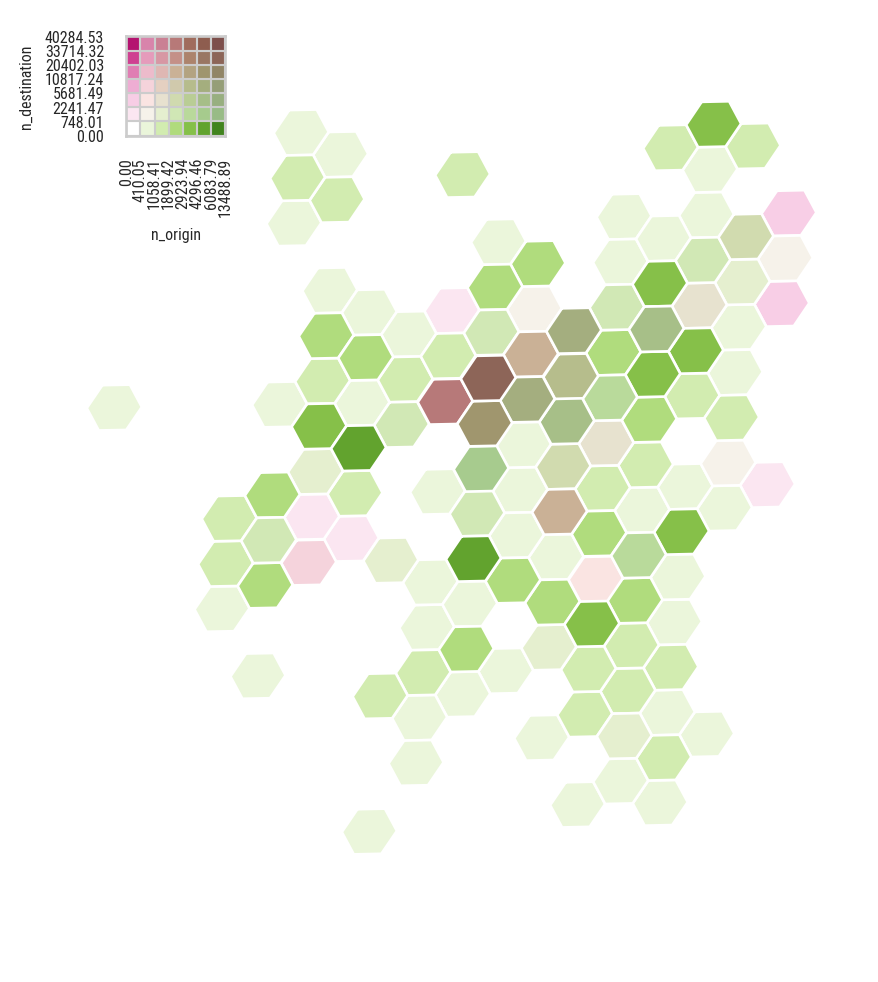

In [28]:
from chiricoca.maps import bivariate_choropleth_map
from chiricoca.maps.utils import add_basemap

ax, palette, cbar_ax = bivariate_choropleth_map(
    grid.join(grid_diff,
        on="h3_cell_id",
        how="inner",
    ),
    "n_origin",
    "n_destination",
    #palette='RdBu_r',
    #edgecolor="none",
    k=7,
    binning='fisher_jenks',
    cbar_args=dict(
        location="upper left", bbox_to_anchor=[0.1, 0.0, 0.8, 1.0], width="15%"
    ),
)

cbar_ax.set_xticklabels(cbar_ax.get_xticklabels(), rotation=90)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07589388696655133..1.1407359479012686].


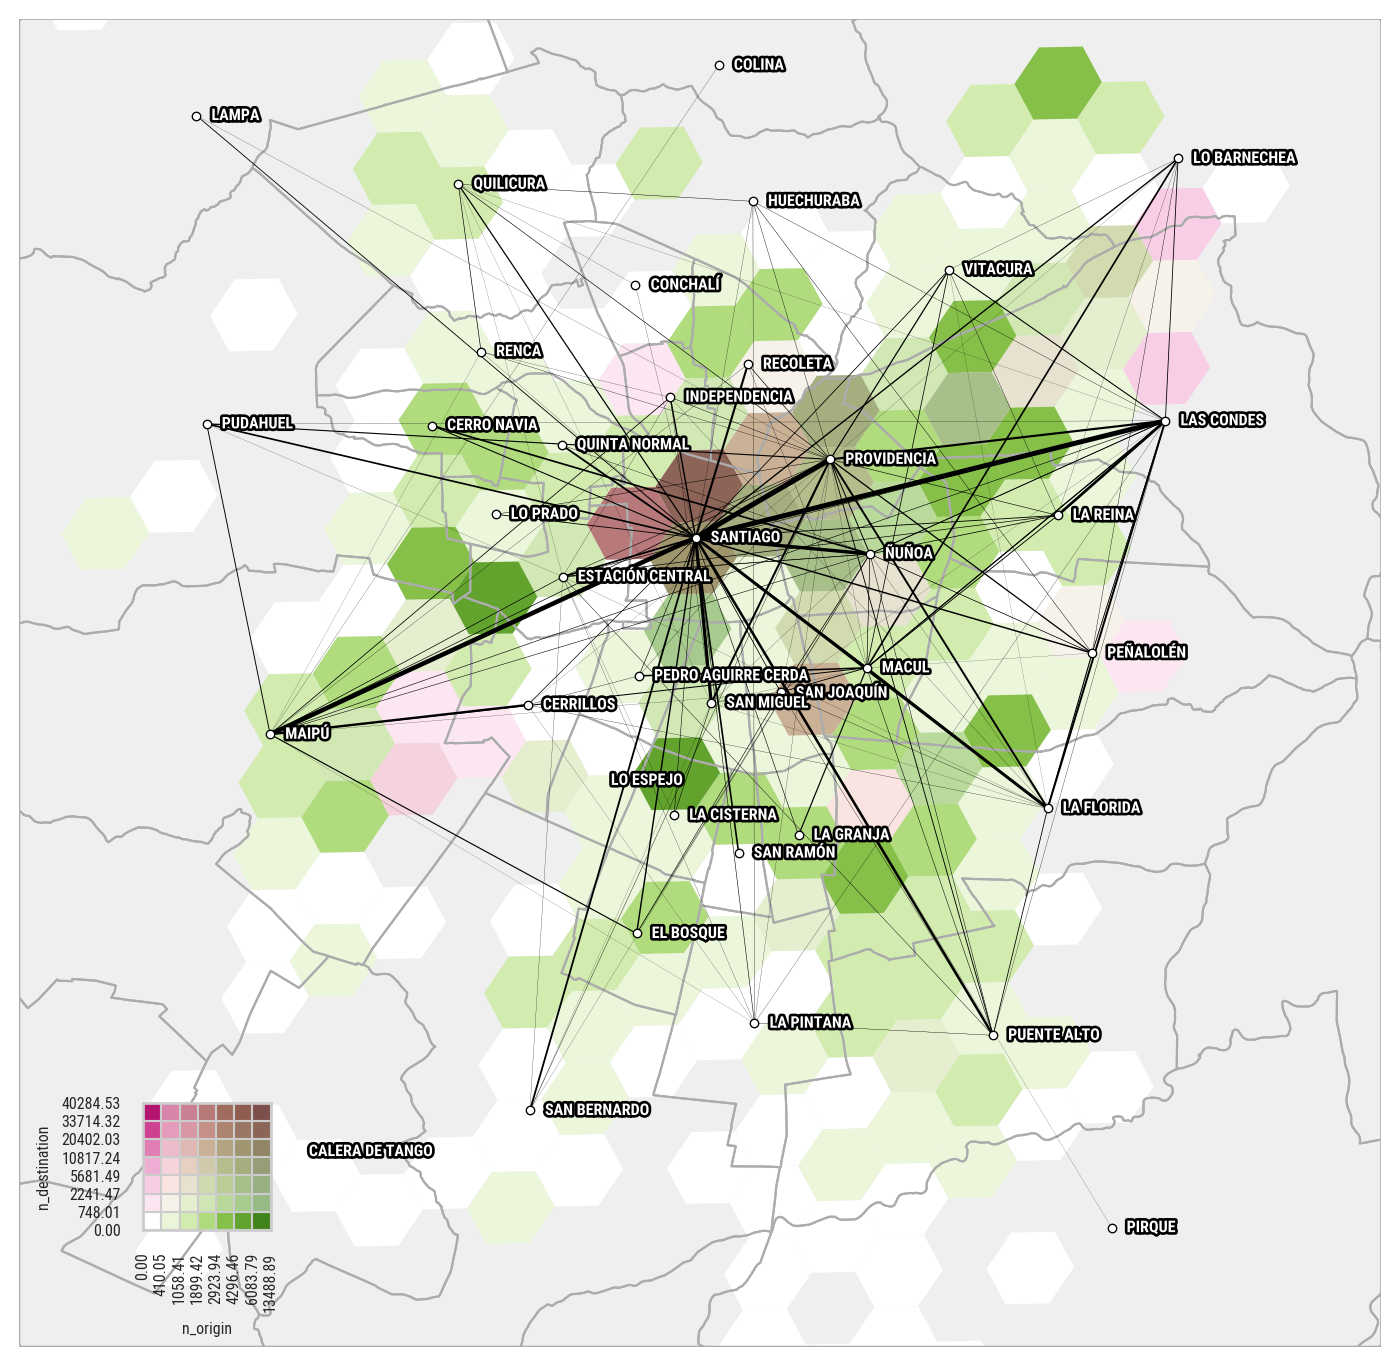

In [33]:
import numpy as np
from chiricoca.maps import choropleth_map
from chiricoca.maps import geographical_labels

fig, ax = figure_from_geodataframe(comunas_urbanas, height=7)

# choropleth_map(grid.join(grid_diff, on='h3_cell_id'), 'n_origin', ax=ax, edgecolor='none', binning='fisher_jenks')

comunas_urbanas.plot(ax=ax, edgecolor="none", facecolor="#efefef")

_, palette, cbar_ax = bivariate_choropleth_map(
    grid.join(
        grid_diff,
        on="h3_cell_id",
        how="inner",
    ),
    "n_origin",
    "n_destination",
    # palette='RdBu_r',
    edgecolor="none",
    k=7,
    binning="fisher_jenks",
    cbar_args=dict(
        location="lower left", bbox_to_anchor=[0.05, 0.08, 0.8, 0.8], width="20%"
    ),
    ax=ax,
)

cbar_ax.set_xticklabels(cbar_ax.get_xticklabels(), rotation=90)

comunas_urbanas.plot(ax=ax, edgecolor="#abacab", facecolor="none")
# add_basemap(ax, Path("data") / "scl_network_basemap.tif", comunas_urbanas)

nx.draw_networkx_edges(
    od_network,
    pos=geo_pos,
    arrows=False,
    width=edge_weight / edge_weight.sum() * 50,
    alpha=1.0,
    ax=ax,
    edge_color="black",
)

nx.draw_networkx_nodes(
    od_network,
    pos=geo_pos,
    node_size=10,
    ax=ax,
    node_color="white",
    edgecolors="black",
    linewidths=0.5,
)

geographical_labels(ax, comunas_urbanas[~comunas_urbanas['NOM_COMUNA'].isin(comunas_a_filtrar)], 'NOM_COMUNA', font_size=6, displacements=(0.005, 0.0), ha='left');

In [30]:
viajes_esup.groupby(['Sexo', 'ModoDifusion'])['Peso'].sum().unstack().T

Sexo,Hombre,Mujer
ModoDifusion,,
Auto,21660.637016,21027.925465
Bicicleta,7263.088850,3679.688665
Bip!,71829.500669,73560.723783
Bip! - Otros Privado,3557.584705,6113.309923
Bip! - Otros Público,3455.138343,2518.038266
Caminata,9255.078371,3305.693677
Otros,5422.934730,1375.031270
Taxi,NaN,250.401357
Taxi Colectivo,470.003350,4093.366938


<Axes: xlabel='DistManhattan', ylabel='ComunaOrigen'>

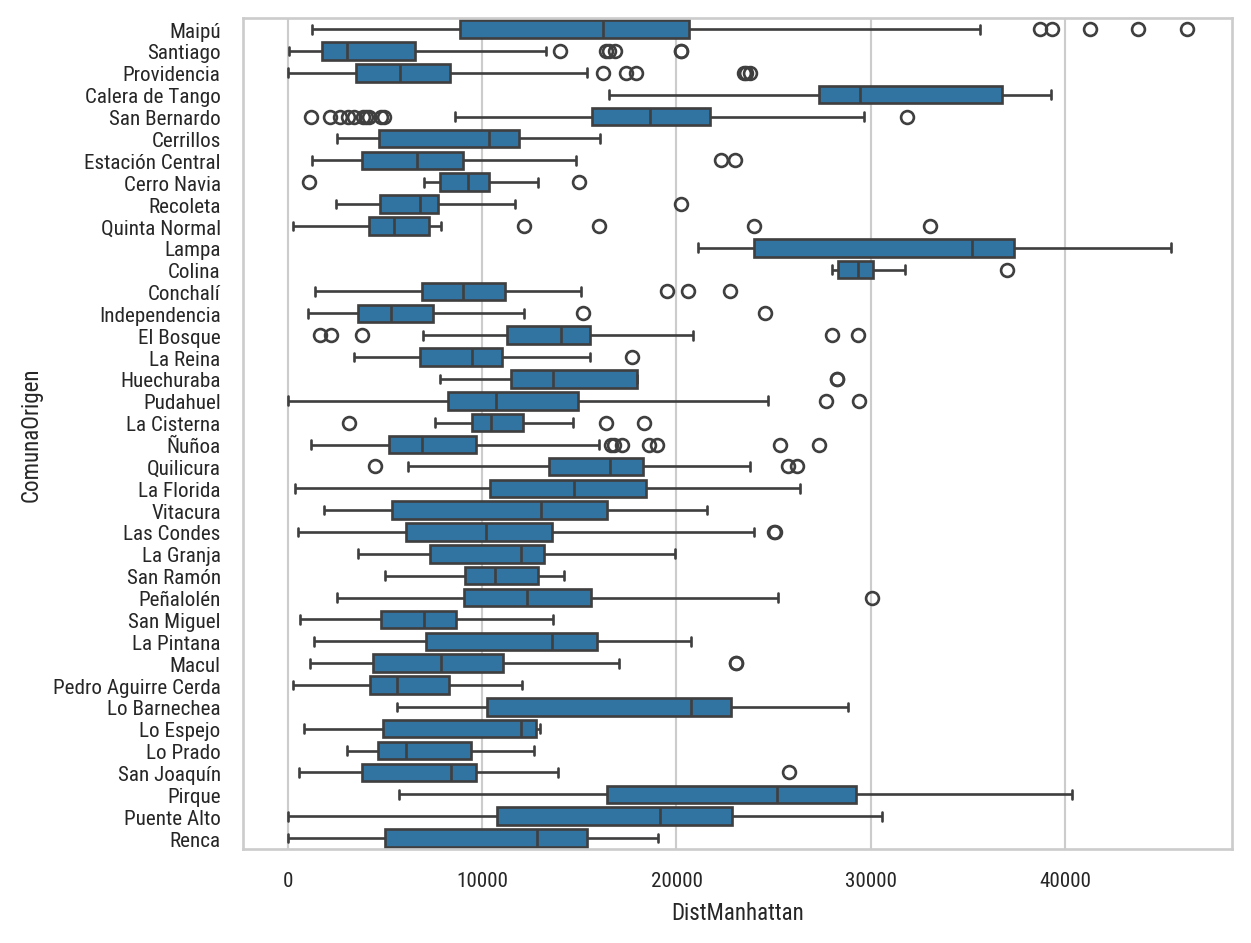

In [56]:
sns.boxplot(viajes_esup[~viajes_esup['ComunaOrigen'].str.upper().isin(comunas_a_filtrar)], y='ComunaOrigen', x='DistManhattan')

In [67]:
orden_comunas = (
    viajes_esup[~viajes_esup['ComunaOrigen'].str.upper().isin(comunas_a_filtrar)].groupby("ComunaOrigen")["DistManhattan"].mean().sort_values(ascending=False)
)

<Axes: xlabel='DistManhattan', ylabel='ComunaOrigen'>

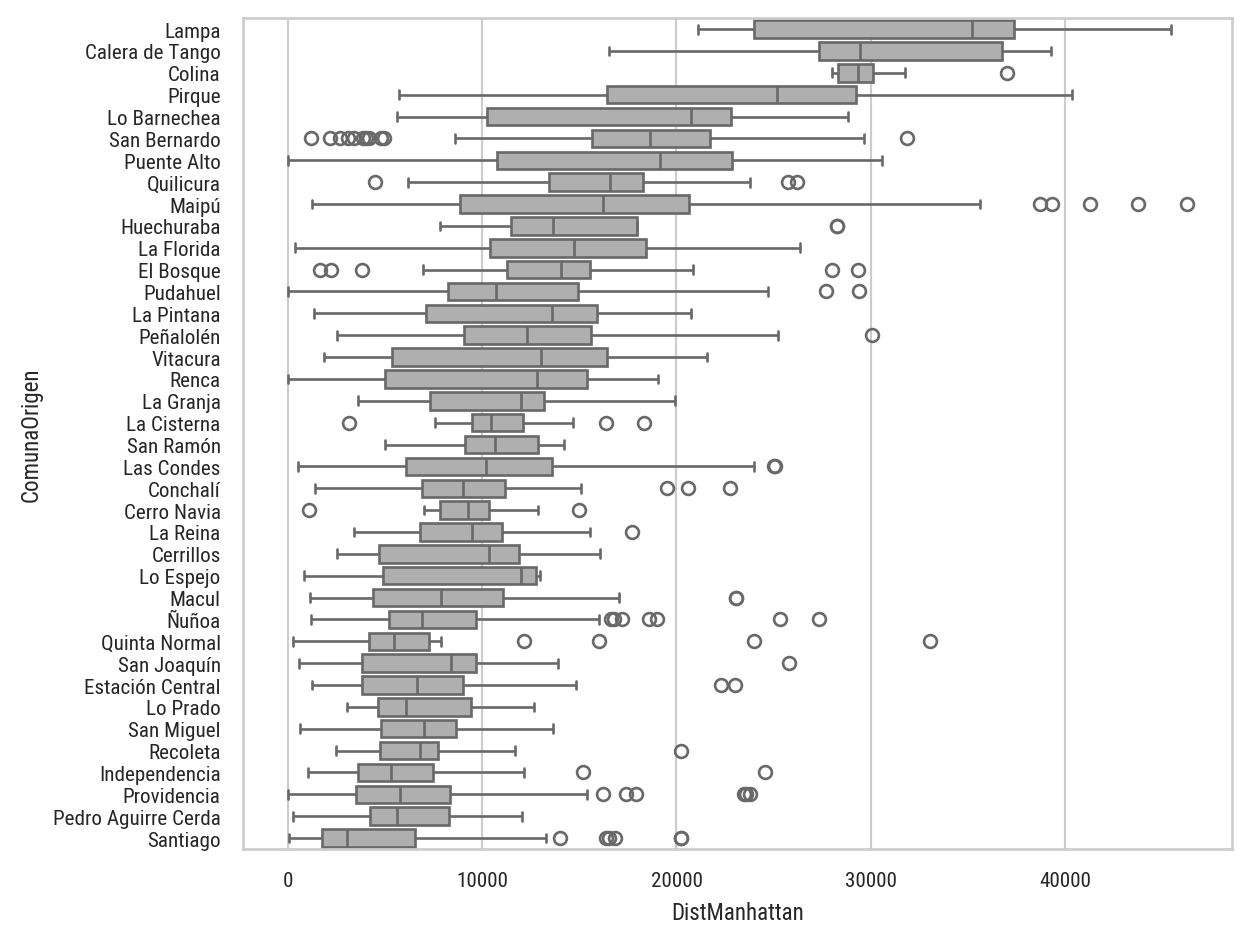

In [68]:
sns.boxplot(viajes_esup, y='ComunaOrigen', x='DistManhattan', order=orden_comunas.index, color='#afafaf')

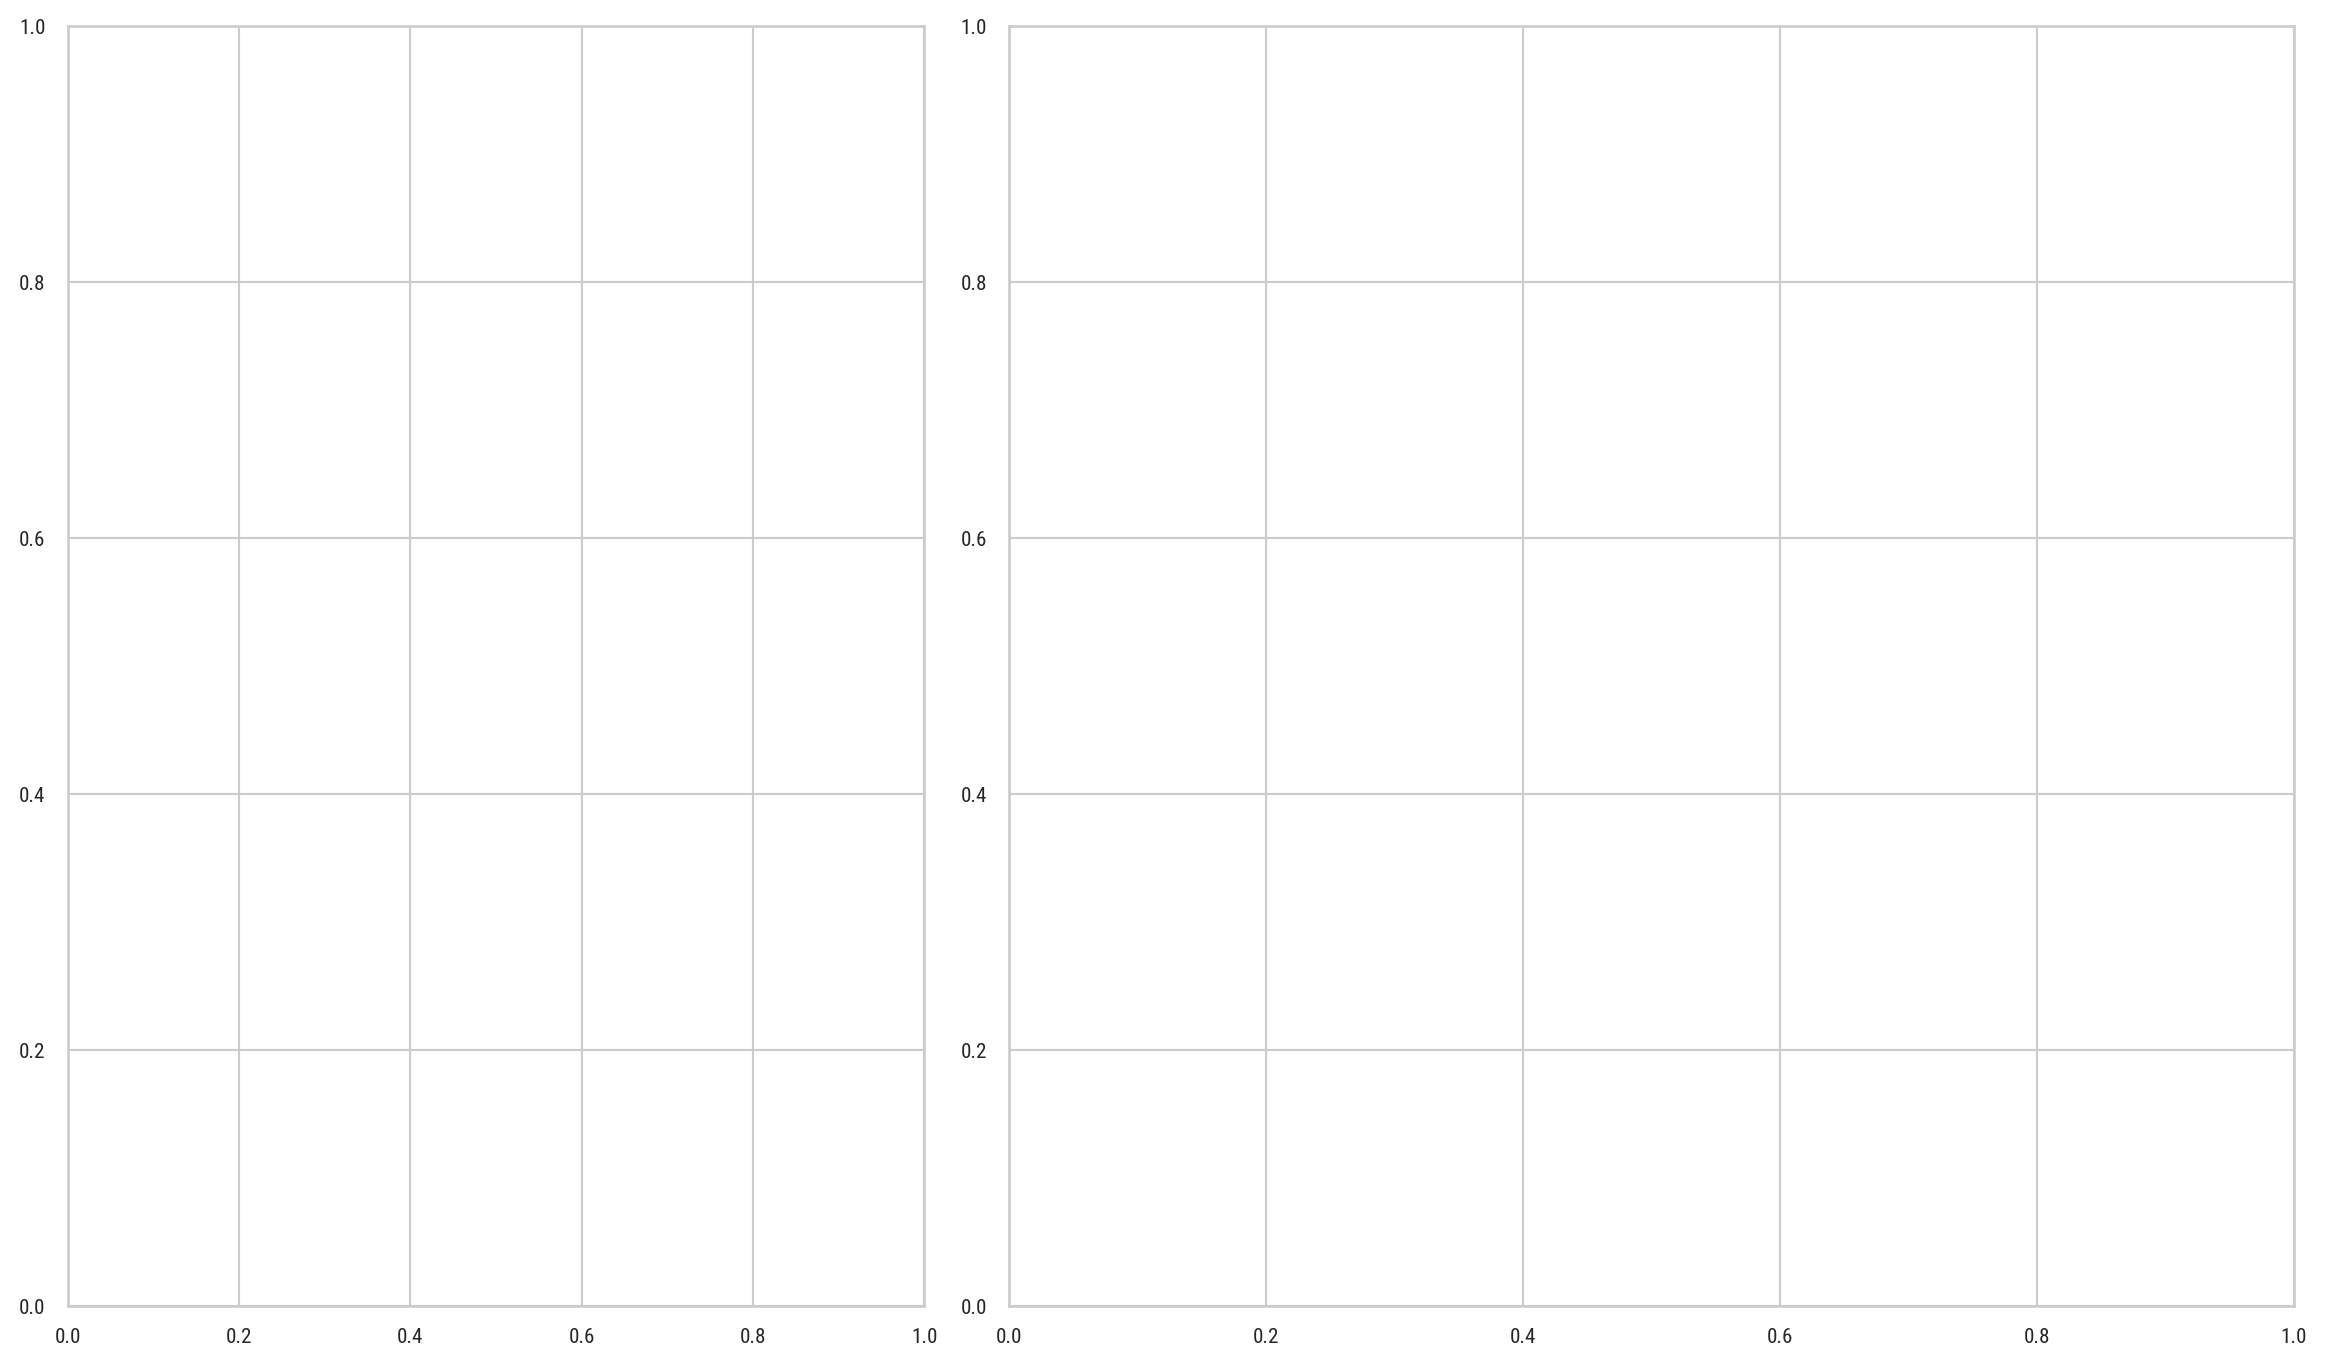

In [77]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 7))

gs = gridspec.GridSpec(
    1,
    2,
    figure=fig,
    #hspace=0.15,
    #wspace=0.05,
    width_ratios=[0.4, 0.6],
)

ax_boxes = fig.add_subplot(gs[0,0])
ax_map = fig.add_subplot(gs[0,1])


/tmp/ipykernel_8348/1900602893.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bounds = comunas_urbanas.buffer(-0.0005).total_bounds
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07589388696655133..1.1407359479012686].


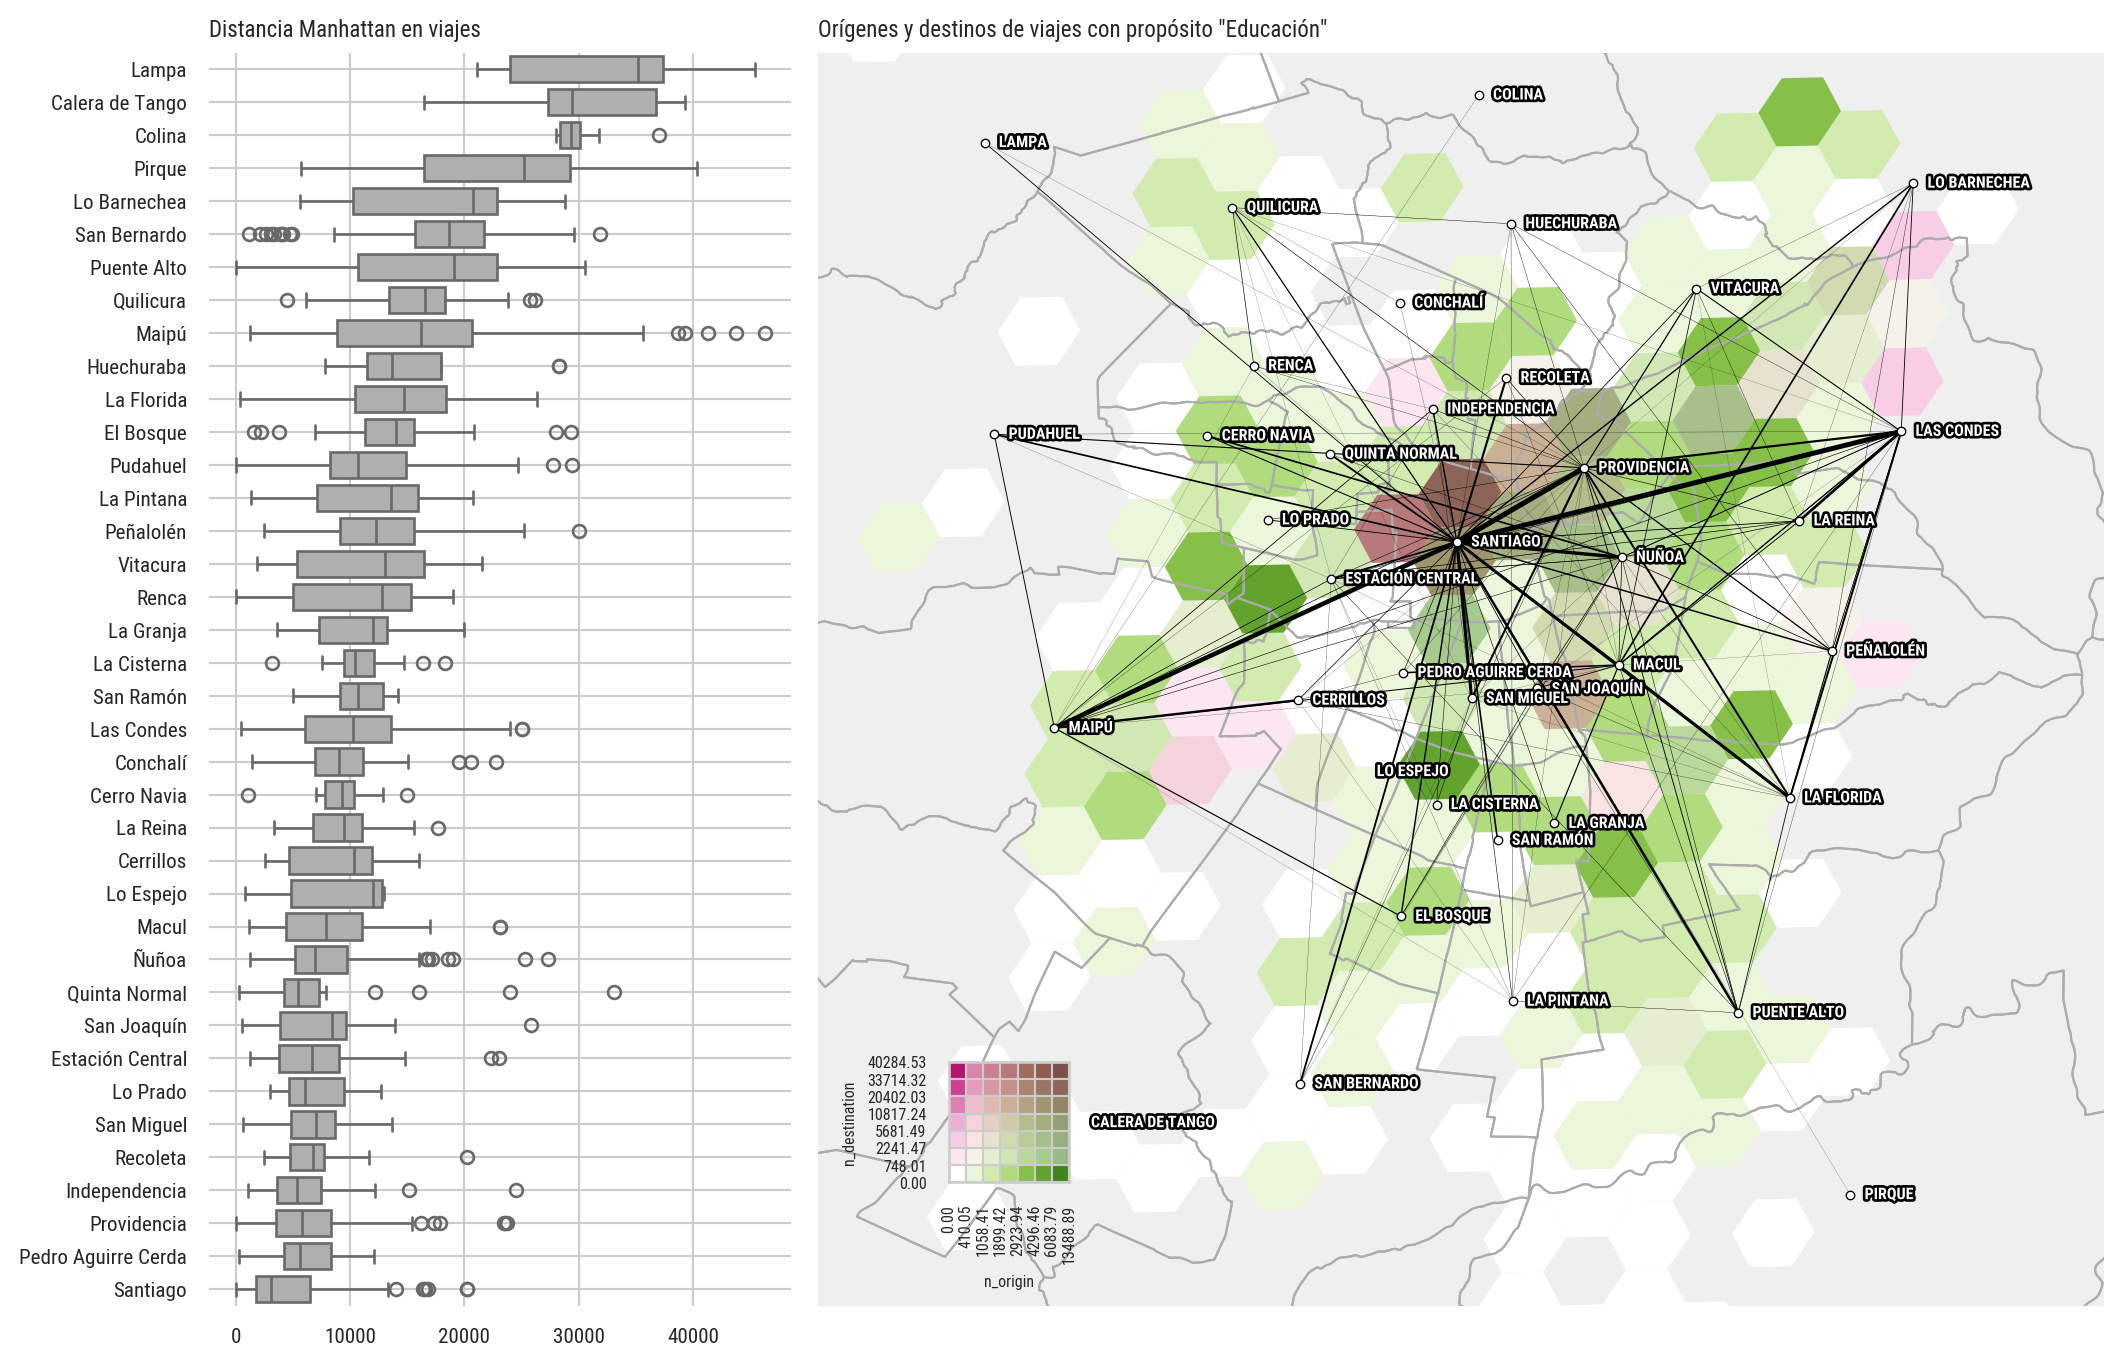

In [111]:
fig = plt.figure(figsize=(11, 7))

gs = gridspec.GridSpec(
    1,
    2,
    figure=fig,
    hspace=0,
    wspace=0,
    width_ratios=[0.89, 2],
)

ax_boxes = fig.add_subplot(gs[0,0])
ax_map = fig.add_subplot(gs[0,1])

sns.despine(ax=ax_boxes, bottom=True, left=True)
ax_map.set_axis_off()
ax_map.set_title('Orígenes y destinos de viajes con propósito "Educación"', loc='left')

sns.boxplot(viajes_esup, y='ComunaOrigen', x='DistManhattan', order=orden_comunas.index, color='#afafaf', ax=ax_boxes)
ax_boxes.set_ylabel('')
ax_boxes.set_title('Distancia Manhattan en viajes', loc='left')
ax_boxes.set_xlabel('')
ax_boxes.grid(True)

bounds = comunas_urbanas.buffer(-0.0005).total_bounds

ax_map.set_xlim([bounds[0], bounds[2]])
ax_map.set_ylim([bounds[1], bounds[3]])
ax_map.set_aspect('equal')

comunas_urbanas.plot(ax=ax_map, edgecolor="none", facecolor="#efefef")

_, palette, cbar_ax = bivariate_choropleth_map(
    grid.join(
        grid_diff,
        on="h3_cell_id",
        how="inner",
    ),
    "n_origin",
    "n_destination",
    # palette='RdBu_r',
    edgecolor="none",
    k=7,
    binning="fisher_jenks",
    cbar_args=dict(
        location="lower left", bbox_to_anchor=[0.06, 0.09, 0.8, 0.8], width="20%"
    ),
    ax=ax_map,
)

cbar_ax.set_xticklabels(cbar_ax.get_xticklabels(), rotation=90)

comunas_urbanas.plot(ax=ax_map, edgecolor="#abacab", facecolor="none")

nx.draw_networkx_edges(
    od_network,
    pos=geo_pos,
    arrows=False,
    width=edge_weight / edge_weight.sum() * 50,
    alpha=1.0,
    ax=ax_map,
    edge_color="black",
)

nx.draw_networkx_nodes(
    od_network,
    pos=geo_pos,
    node_size=10,
    ax=ax_map,
    node_color="white",
    edgecolors="black",
    linewidths=0.5,
)

geographical_labels(ax_map, comunas_urbanas[~comunas_urbanas['NOM_COMUNA'].isin(comunas_a_filtrar)], 'NOM_COMUNA', font_size=6, displacements=(0.005, 0.0), ha='left');